<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p  style="line-height:10px; font-size: 18px; text-align:center; font-family: BTitrBold,'BTitrBold',tahoma; font-weight: bold;">
        Apple and Orange Fruit Classification into Two Classes (Healthy and Rotten)
        </p>
        <p  style="line-height:10px; font-size: 18px; text-align:center; font-family: BTitrBold,'BTitrBold',tahoma;">
        Student Name: Baran Khatibi
        </p>
        <p style="line-height:10px; font-size: 16px; text-align:center; font-family: BTitrBold,'BTitrBold',tahoma;">
           The implementation was done using the Jupyter Notebook environment.
        </p>
    </body>
</html>

In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p dir ='ltr' style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
            In this section, you can see some sample images from the dataset, including healthy and rotten apples and oranges.
            The labeling method for these fruits is as follows:
        </p>
        <ol dir ='ltr' style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
            <li>Class 1 for healthy fruits</li>
            <li>Class 2 for rotten fruits</li>
        </ol>
    </body>
</html>

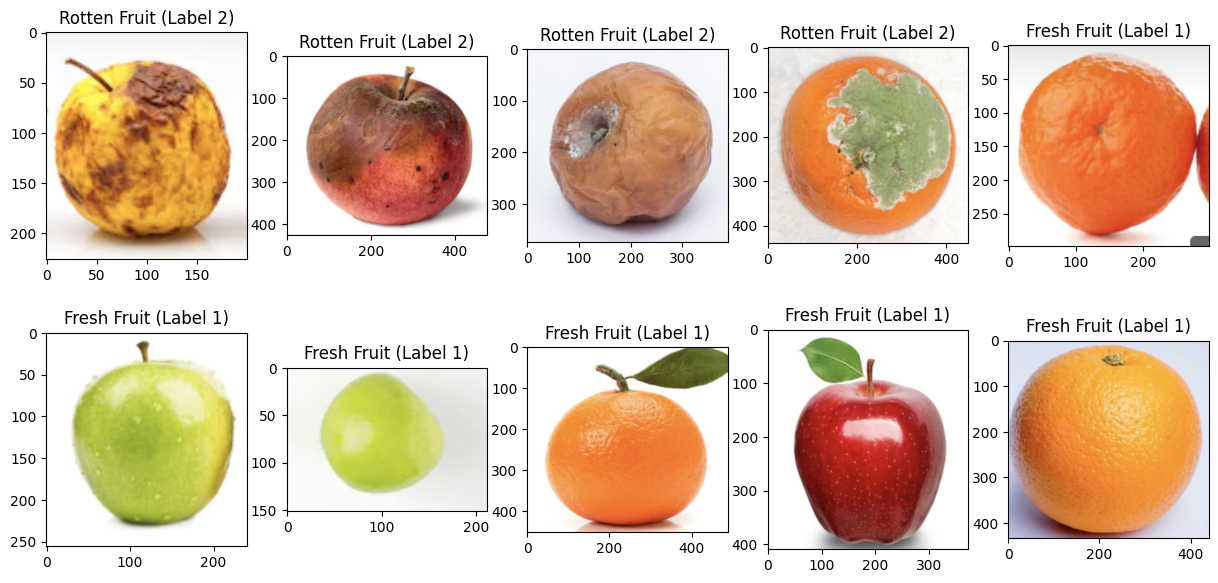

In [22]:
plt.rcParams['figure.figsize'] = [15, 7]
for i, entry in enumerate(os.scandir('data/rotten')):
    a = entry.path
    img = cv2.imread(a)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,5,i+1)
    plt.title('Rotten Fruit (Label 2)')
    plt.imshow(img_rgb)
    if i >= 5: break

for i, entry in enumerate(os.scandir('data/fresh')):
    a = entry.path
    img = cv2.imread(a)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,5,i+5)
    
    plt.title('Fresh Fruit (Label 1)')
    plt.imshow(img_rgb)
    if i >= 5: break

# preprocessing 

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p  style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
        This section includes contrast enhancement, sharpening, segmentation, and background removal, which are done before training the model.
        </p>
    </body>
</html>

## enhancement

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
This algorithm applies contrast stretching depending on the type of image (dark, bright, or faded). 
            To implement this algorithm, a color model is used that separates color from brightness, so the color of the image is not changed.
        </p>
    </body>
</html>

In [23]:
def enhancement(img_rgb): 
    
    height, width= img_rgb.shape[:2]
    
    #contrast enhancement using histogram equalization
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    h,s,v = cv2.split(img_hsv)
     
    v_f = v.flatten()
    
    #getting the frequnecy
    freq = np.array(range(256))
    for k in v_f:
        freq[k] += 1
   
    pr = freq/np.sum(freq)
    csum = pr.cumsum()
    sprime = csum * 255
    rnd=np.round(sprime)
     
    o = len(v_f)
    for i in range(o):
        a = v_f[i]
        v_f[i] = rnd[a]

    new_v = np.reshape(v_f, (height, width))
    
    hsv2 = cv2.merge((h,s,new_v))
    new_rgb = cv2.cvtColor(hsv2, cv2.COLOR_HSV2RGB)
    return new_rgb
        

### edge detection

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p  style="font-size: 18px;  text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
In the edge detection step, the Laplacian operator is used. Based on what was discussed in class, 
            when the direction of the edges is not needed, the Laplacian provides better results. 
            Here, a 3×3 mask size is used.
        </p>
    </body>
</html>

In [24]:
def edge_detection(image):
    edges = cv2.Laplacian(image, cv2.CV_16S, ksize=3)
    return edges

### sharpening

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
 In the sharpening step, the detected edges from the previous stage are added to the original image, 
            resulting in a sharpened image.
        </p>
    </body>
</html>

In [25]:
def sharpening(img, edge):
    r, g, b = cv2.split(img)
    er, eg, eb= cv2.split(edge)

    nr = r + er
    ng = g + eg
    nb = b + eb

    image = cv2.merge((nr,ng,nb))
    return image

### segmentation

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
For segmentation and clustering, the K-means method was used. After some trial and error, 
            the number of clusters was set to 6. Using this method also helps reduce the preprocessing time.
        </p>
    </body>
</html>

In [26]:
def segmentation(img_rgb):
    img_2d = img_rgb.reshape((-1, 3))
    img_2d = np.float32(img_2d)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 300, 0.3)

    k = 6
    element1, label, centers = cv2.kmeans(img_2d, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

    centers = np.uint8(centers)
    label_f = label.flatten()

    result = centers[label.flatten()]
    result = result.reshape(img_rgb.shape)
    return result



### background remover

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p  style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
In this part, we use the clustered image from the previous step to remove the background. 
            In the dataset, the background is white and contains shadows, but because K-means clustering was used, 
            the shadows were removed and the image became more uniform. 
            To remove the white background, we identify the cluster with the highest RGB values 
            (the brightest cluster) as the background and remove it by converting it into a dark background.
        </p>
    </body>
</html>

In [27]:
def bgremoval(img, segmented_image):
    
    height, width = img.shape[:2]
    
    maxx = segmented_image.max()

    r,g,b = cv2.split(img)
    r_f = r.flatten()
    g_f = g.flatten()
    b_f = b.flatten()

    er, eg, eb = cv2.split(segmented_image)

    er_f = er.flatten()
    eg_f = eg.flatten()
    eb_f = eb.flatten()

    for i in range(len(er_f)):
        if (er_f[i] == maxx  or eg_f[i] == maxx or eb_f[i] == maxx):
            r_f[i] = 0
            g_f[i] = 0
            b_f[i] = 0


    new_r = np.reshape(r_f, (height, width))
    new_g = np.reshape(g_f, (height, width))
    new_b = np.reshape(b_f, (height, width))


    removed = cv2.merge((new_r,new_g,new_b))
    
    return removed

In [31]:
def preprocess(img):
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    enhanced = enhancement(img_rgb)
    edged = edge_detection(enhanced)
    sharpened = sharpening(img_rgb, edged)
    segmented = segmentation(sharpened)
    bgremoved = bgremoval(img_rgb, segmented)

    return bgremoved

#### finding the minimum shape for resizing all the images

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p  style="font-size: 18px; text-align:;left; font-family: BTitrBold,'BTitrBold',tahoma;">
 Since we need all images to have the same dimensions to extract pixels as features, we use the resize method. 
            To make all images the same size, we take the minimum value from the width and the height across all images.
        </p>
    </body>
</html>

In [28]:
def findingMin():
    minh = float('inf')
    minw = float('inf')
    for entry in os.scandir('data/all'):  
        a = entry.path
        img = cv2.imread(a)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        height, width = img_rgb.shape[:2]
        if height <= minh and width <= minw:
            minh = height
            minw = width
    return minh, minw

### feature exctraction

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
In the feature extraction step, in addition to using the pixel values themselves 
            (the average R, G, and B of each pixel), the average grayscale values of R, G, and B 
            were also used separately as features. 
            These features are stored in a Pandas DataFrame so that we can build a feature matrix.  
            The last column of this matrix naturally corresponds to the class label:  
            Class 1 for healthy fruit images, and Class 2 for rotten fruit images.
        </p>
    </body>
</html>

In [29]:
minh, minw = findingMin()
names = [ 'pixel' + str(i) for i in range(minh*minw)]
columns = ['mean_R', 'mean_G', 'mean_B'] + names + ['label']
data = list()

##### fresh fruits

In [ ]:
for entry in os.scandir('data/fresh'):  
    a = entry.path
    img = cv2.imread(a)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    #preprocessing
    enhanced = enhancement(img_rgb)
    edged = edge_detection(enhanced)
    sharpened = sharpening(img_rgb, edged)
    segmented = segmentation(sharpened)
    bgremoved = bgremoval(img_rgb, segmented)

    
    #feature exctraction
    label=1

    
    #feature one
    rm = int(np.mean(bgremoved[:, :, 0]))
    gm = int(np.mean(bgremoved[:, :, 1]))
    bm = int(np.mean(bgremoved[:, :, 2]))
    
    #feature two
    dimension = (minh, minw)
    resized = cv2.resize(img_rgb, dimension )    
    feature2 = np.mean(resized, axis=2, dtype = int).flatten()        
       
    features = [rm, gm, bm] + [pixel for pixel in feature2] + [label]    
        
    data.append(features)


##### rotten fruits

In [ ]:
for entry in os.scandir('data/rotten'):  
    a = entry.path
    img = cv2.imread(a)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


    #preprocessing
    enhanced = enhancement(img_rgb)
    edged = edge_detection(enhanced)
    sharpened = sharpening(img_rgb, edged)
    segmented = segmentation(sharpened)
    bgremoved = bgremoval(img_rgb, segmented)

    
    #feature exctraction
    label=2

    
    #feature one
    rm = int(np.mean(bgremoved[:, :, 0]))
    gm = int(np.mean(bgremoved[:, :, 1]))
    bm = int(np.mean(bgremoved[:, :, 2]))
    
    #feature two
    dimension = (minh, minw)
    resized = cv2.resize(img_rgb, dimension )    
    feature2 = np.mean(resized, axis=2, dtype = int).flatten()        
       
    features = [rm, gm, bm] + [pixel for pixel in feature2] + [label]    
        
    data.append(features)


###### creating a pandas DataFrame

In [ ]:
df = pd.DataFrame(data, columns=columns)

In [ ]:
df

###### dividing our data into train and test sets

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p  style="font-size: 18px; text-align:left; font-family: BTitrBold,'BTitrBold',tahoma;">
        Using the <code>split_train_test</code> method, the dataset is first shuffled to randomize the order of the samples. 
            Then, it is divided into two parts: train and test, with a ratio of 0.8 to 0.2.
            <br><br>
            Next, the training data is used to train an SVM classifier. The feature matrix and the expected labels 
            are given to the model, and an SVM model is created based on the training data.
        </p>
    </body>
</html>

In [14]:
train, test = train_test_split(df, test_size=0.2)
y = train.label
x = train.drop("label", axis=1)


In [ ]:
train

,mean_R,mean_G,mean_B,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,...,pixel17559,pixel17560,pixel17561,pixel17562,pixel17563,pixel17564,pixel17565,pixel17566,pixel17567,label
411,217,190,159,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,1
82,132,62,61,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,1
489,130,77,56,255,255,255,255,255,255,255,...,230,232,233,233,233,233,233,233,234,2
322,167,101,58,255,255,255,255,255,255,255,...,253,253,253,253,254,254,253,253,254,1
865,133,81,57,255,255,255,255,255,255,255,...,253,253,253,253,253,253,253,254,254,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
810,137,91,43,251,252,252,252,251,250,250,...,254,254,255,255,255,255,255,255,255,2
223,162,148,72,255,255,255,255,255,255,255,...,253,253,252,252,251,249,249,247,245,1
673,110,74,52,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,2
782,126,96,69,246,246,246,246,246,246,246,...,237,237,237,237,238,238,237,236,237,2


In [16]:
test

,mean_R,mean_G,mean_B,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,...,pixel17559,pixel17560,pixel17561,pixel17562,pixel17563,pixel17564,pixel17565,pixel17566,pixel17567,label
912,113,89,77,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,2
340,149,89,49,255,255,255,255,255,255,255,...,244,244,244,244,244,244,244,244,246,1
442,112,78,58,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,2
375,131,86,44,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,1
611,219,181,143,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
586,116,87,72,245,245,245,245,245,245,245,...,244,244,244,244,244,244,244,244,244,2
451,126,86,68,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,2
100,116,105,58,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,1
460,97,68,44,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,2


### Training

In [17]:
classifier = svm.SVC()
classifier.fit(x,y)

SVC()

<html>
    <head>
        <link href='http://www.fontonline.ir/css/Mj_Silicon.css' rel='stylesheet' type='text/css'>
    </head>
    <body>
        <p dir="rtl" style="font-size: 16px; text-align:right; font-family: BTitrBold,'BTitrBold',tahoma;">
در این قسمت درصد دقت عملکرد مدل را مشاهده می کنیم که در سلول اول درصد دقت کلاس اول یعنی کلاس میوه های سالم و در سلول دوم درصد دقت کلاس میوه های خراب و در سلول آخر به طور کلی درصد دقت مدل را می بینیم.
        </p>
    </body>
</html>

#### accuracy of the fresh fruits class

In [18]:
testOne = test[test.label == 1]

yTestOne = testOne.label
xTestOne = testOne.drop('label', axis = 1)

yPredOne = classifier.predict(xTestOne) 

accOne = metrics.accuracy_score(yTestOne, yPredOne)
print(accOne)

0.6129032258064516


#### accuracy of the rotten fruits class

In [19]:
testTwo = test[test.label == 2]

yTestTwo = testTwo.label
xTestTwo = testTwo.drop('label', axis = 1)

yPredTwo = classifier.predict(xTestTwo) 

accTwo = metrics.accuracy_score(yTestTwo, yPredTwo)
print(accTwo)

0.8476190476190476


##### calculating the accuracy of the model

In [20]:
ytest = test.label
xtest = test.drop('label', axis = 1)

ypred = classifier.predict(xtest)

acc = metrics.accuracy_score(ytest, ypred)
print(acc)

0.7373737373737373
